# 线性回归 & 基础优化

## 线性回归
### **引入：买房建模**

把房子成交价的**影响因素**如**房间数**、**卫生间数**、**居住面积**‘量化’为**x1、x2、x3**。

我们将权重设为**w**向量

### 1.1单层神经网络
**单层**：指影响因素只有一层。

**神经网络**：源于神经科学：输入--计算--输出

### 1.2平方损失
l(y,ybar) = 1/2(y-ybar)^2

### 1.3训练数据

收集数据点来决定参数值    --训练数据

**训练样本**： X=[] (目前不会公式书写)

### 1.4参数学习
求训练损失--最小化损失来使误差最小（误差损失最小），从而得到最合适的**w***和**b***

### 1.5显示解（只在线性模型使用）
将偏差加入权重，即拓展**w**和**b**两个张量，使得拓展后的**Xw**=原来的**Xw+b**

## 基础优化
### 2.1梯度下降
指定初始值**w0**，迭代接近最优解，最快沿着梯度方向增加损失函数值（负梯度）。

其中，学习率需要人为设置
### 2.2像批量随机梯度下降（深度学习默认求解算法）
原因：整个训练集算梯度太贵，时间长。

批量大小选择上，不能过小（未并行，资源利用不充分）、过大（浪费计算增加内存消耗）

两个重要超参数：**η**（学习率），**b**（批量大小）

###### *超参数人为设置，参数由学习得出*

## 3.2线性回归从零实现

In [1]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

### 坎
P:这里是本人第一次导入d2l库，最开始是未安装，我使用了pip指令在conda环境中安装d2l 1.0.3版本，遭遇了与numpy版本不兼容的问题，可以通过在文件管理器中修改对应文件内的内容实现。

具体操作：
1. 在文件管理器下载库的地方（envs）找到d2l的相关文件夹
2. 找到一个metadata文件，用记事本打开。
3. 查找你的numpy版本，在上面那个文件中numpy==“版本号”填入你当前numpy版本

### 3.2.1实操部分：生成数据集
下面，定义生成数据集的函数

In [2]:
def synthetic_data(w, b, num_examples):  #w，b，样本数
    X = torch.normal(0 ,1 ,(num_examples, len(w)))
    #生成形状为（num_examples, len(w)）的矩阵X，其中每个元素从均值为0，σ=1的正态分布中随机抽取
    y = torch.matmul(X, w) + b           #对X,w进行矩阵乘法计算
    y += torch.normal(0,0.01,y.shape)    #噪声加入y中（σ=0.01很小，视作误差）
    return X,y.reshape((-1,1))           #y重塑为列向量形式(reshape函数使用)

true_w = torch.tensor([2.0,-3.4])         #2.0改张量为float类型
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

`torch.normal(μ,σ,shape)`:在正态分布（normal distribute）中随机抽取元素

`torch.matmul(A,B)`:将矩阵A，B矩阵相乘

`reshape(-1,k)`:-1指该维度的大小，使得元素个数不变。最后形状为(n/k,k),n要能整除k，否则报错

并且，`matmul`函数对相乘的矩阵有要求，正态分布生成的矩阵为float类型，那其相乘的张量也需要为float类型

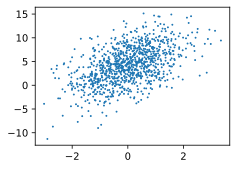

In [3]:
d2l.set_figsize()
d2l.plt.scatter(features[:,0].detach().numpy(),labels.detach().numpy(),1)

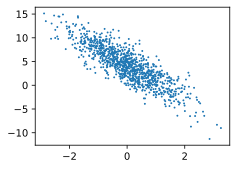

In [4]:
d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

两幅图反映了X的两个影响因素**各自**与labels之间的关系，具有明显线性，到现实含义中可以理解为房龄、面积（影响因素）各自与房价（labels）的关系

### 3.2.2读取数据集
接下来定义一个`data_iter`函数，接收批量大小、特征矩阵（X），标签向量（y），生成大小为`batch_size`的小批量数据

即**创造样本**

In [5]:
def data_iter(batch_size,features,labels):
    num_examples = len(features)
    indices = list(range(num_examples)) #生成同样数量的index（下标），构成列表：[0,1,2……,num_examples-1]
    random.shuffle(indices)             #打乱列表
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i:min(i+batch_size, num_examples)])
        #该批量对应的索引（随机），作为接下来的切片位置,取min保证不超出样本数
        yield features[batch_indices],labels[batch_indices] #进行切片（行索引）

batch_size = 10

for X, y in data_iter(batch_size, features, labels): #yield相当于返回了这一次循环里features,labels的切片
    torch.set_printoptions(sci_mode=False)           #让它输出小数，不带e，好看一点
    print(X, '\n',y)
    break
    

tensor([[-1.3531,  0.9865],
        [ 0.0323,  0.9784],
        [ 0.1801,  0.6121],
        [-0.7684,  0.3402],
        [-0.1910,  0.7967],
        [ 0.6712,  0.4992],
        [-0.1350,  0.5932],
        [-0.3624, -1.6001],
        [-0.5061, -1.3397],
        [-0.4458, -0.2297]]) 
 tensor([[-1.8592],
        [ 0.9335],
        [ 2.4913],
        [ 1.4978],
        [ 1.1173],
        [ 3.8484],
        [ 1.9129],
        [ 8.9118],
        [ 7.7402],
        [ 4.1003]])


设有张量**A**，**B**，则`A[B]`表示张量**A**在**B**所表示的位置的切片，若**B**为一维张量，默认dim=0（按行索引）

定义初始化模型参数

In [6]:
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
w,b

(tensor([[0.0084],
         [0.0111]], requires_grad=True),
 tensor([0.], requires_grad=True))

定义模型

In [7]:
def linreg(X, w, b):
    return torch.matmul(X, w) + b

定义损失函数

In [8]:
def squared_loss(y_hat, y):
    return (y.reshape(y_hat.shape) - y_hat)**2 / 2 #注意返回的还是一个向量

定义优化算法

In [9]:
def sgd(params, lr, batch_size): #param为参数，lr为学习率
    with torch.no_grad():
        for param in params:
            param -=lr * param.grad /batch_size 
            #朝梯度方向减，因为梯度是loss.sum().backward()所得（把矩阵元素求和后再求的导），为各样本的梯度总和，故需要除以样本数(批量数)
            param.grad.zero_()
            

我在写这里的时候的疑惑：这个`for`循环*何意味*？

我自己（看了ai）的解释，这个`params`可以是多层的权重[**w**,**b**]组成的多维张量，就能一个函数计算多层导数实现链式求导？

接下来进行实现：

In [10]:
lr = 0.01
num_epochs = 4
net = linreg
loss = squared_loss

for epoch in range(num_epochs) :
    #求y_hat-求loss-导出grad-梯度下降
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b),y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)
    with torch.no_grad():
        train_1 = loss(net(features, w, b), labels)
        print(f'epoch: {epoch+1}, loss:{float(train_1.sum()/batch_size):f}')

epoch: 1, loss:224.901398
epoch: 2, loss:30.878687
epoch: 3, loss:4.246723
epoch: 4, loss:0.588608


In [11]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([ 0.0321, -0.0702], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0772], grad_fn=<RsubBackward1>)


我是菜狗，我看了书和视频至少6个小时才搞明白、理清楚各个过程

## 线性回归简洁实现
我们在之前已经打好了框架，也就是体验了造轮子的过程。现在，我们直接把别人造好的轮子搬过来用。好比只需要在说明书里写：“把轮子装上”而不用写“轮子的制作过程：……”

下方的具体过程及代码描述见 [https://zh-v2.d2l.ai/] 中的3.3章节（我也不了解这些库）

In [12]:
import numpy as np
import torch
from torch.utils import data
from d2l import torch as d2l

#生成数据集
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = d2l.synthetic_data(true_w, true_b, 1000)

#读取数据
def load_array(data_arrays, batch_size, is_train=True):  #@save
    """构造一个PyTorch数据迭代器"""
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset, batch_size, shuffle=is_train)

batch_size = 10
data_iter = load_array((features, labels), batch_size)

next(iter(data_iter))

#定义这个模型
from torch import nn

net = nn.Sequential(nn.Linear(2, 1)) 

#初始化参数：w&b
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

#定义损失，MSE直接得到所以样本损失的平均值
loss = nn.MSELoss()

#定义算法，只需要设置lr
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

#进行训练
num_epochs = 3 #把epoch翻译为轮次
for epoch in range(num_epochs):
    for X, y in data_iter:
        l = loss(net(X) ,y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features), labels)
    print(f'epoch {epoch + 1}, loss {l:f}')

w = net[0].weight.data
print('w的估计误差：', true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print('b的估计误差：', true_b - b)

epoch 1, loss 0.000225
epoch 2, loss 0.000102
epoch 3, loss 0.000104
w的估计误差： tensor([ 0.0013, -0.0014])
b的估计误差： tensor([0.0005])
